# The Upset Report: FIFA World Cup 2026 Match Analytics

**A data story of the first 48-team World Cup, from the opening kickoff to the final whistle.**

This notebook analyzes every match, goal, card, and squad from the 2026 FIFA World Cup using the [FIFA-World-Cup-2026-Dataset](https://github.com/mominullptr/FIFA-World-Cup-2026-Dataset) (teams, matches, match events, team stats, squads), patched with the confirmed final result (Spain 1–0 Argentina, AET) which the source dataset had not yet logged at the time of writing.

**What this notebook covers:**
1. Data loading and cleaning
2. Tournament-wide statistics (goals, cards) vs. 2018 and 2022
3. Shock wins and statement draws, measured against pre-tournament FIFA rankings
4. Near-miss stories with minute-by-minute goal timelines
5. Squad value vs. how far each team actually went
6. Host nation performance
7. Golden Boot vs. team success
8. Argentina's expected-goals collapse in the final

Built by Cortana Oladele.


## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#0F1F1A",
    "figure.facecolor": "#0A1512",
    "axes.edgecolor": "#1E3A30",
    "grid.color": "#1E3A30",
    "text.color": "#F4F1E6",
    "axes.labelcolor": "#F4F1E6",
    "xtick.color": "#7FA090",
    "ytick.color": "#7FA090",
})
GOLD, RED, TEAL = "#FFC53D", "#FF5C5C", "#2FE0C4"
plt.rcParams['figure.dpi'] = 110


In [2]:
teams = pd.read_csv('teams.csv')
matches = pd.read_csv('matches_detailed.csv')
events = pd.read_csv('match_events.csv')
team_stats = pd.read_csv('match_team_stats.csv')
squads = pd.read_csv('squads_and_players.csv')
features = pd.read_csv('match_prediction_features.csv')

print(f"Teams: {len(teams)}")
print(f"Matches: {len(matches)}")
print(f"Match events: {len(events)}")
print(f"Team-match stat rows: {len(team_stats)}")
print(f"Players: {len(squads)}")


Teams: 48
Matches: 104
Match events: 827
Team-match stat rows: 206
Players: 1248


### Patching the final

The source dataset was pulled before the final had been played. The result below (Spain 1–0 Argentina, AET, Ferran Torres 106', Enzo Fernández red card in stoppage time) is patched in manually, cross-checked against FIFA's own match center and post-final reporting.

In [3]:
matches.loc[matches.match_id == 104, ['home_score','away_score','status','result_type','home_xg','away_xg']] = \
    [1, 0, 'Completed', 'AET', 1.94, 0.20]

completed = matches[matches.status == 'Completed'].copy()
print(f"Completed matches: {len(completed)} / {len(matches)}")
completed[completed.match_id == 104][['home_team_name','away_team_name','home_score','away_score','result_type']]


Completed matches: 104 / 104


,home_team_name,away_team_name,home_score,away_score,result_type
103,Spain,Argentina,1,0,AET


## 2. Tournament-wide stats: how does 2026 compare to 2018 and 2022?

In [4]:
total_goals = (completed.home_score + completed.away_score).sum()
goals_per_match = total_goals / len(completed)

card_counts = events[events.event_type.isin(['Yellow Card','Red Card'])].event_type.value_counts()
total_cards = card_counts.sum()
cards_per_match = total_cards / len(completed)

print(f"2026: {len(completed)} matches, {total_goals} goals ({goals_per_match:.2f}/match)")
print(f"2026 cards: {dict(card_counts)}  ->  {cards_per_match:.2f} cards/match")


2026: 104 matches, 308 goals (2.96/match)
2026 cards: {'Yellow Card': np.int64(248), 'Red Card': np.int64(14)}  ->  2.52 cards/match


In [5]:
historical = pd.DataFrame([
    {"year": 2018, "teams": 32, "matches": 64, "goals": 169, "goals_per_match": 2.64, "cards_per_match": 3.48},
    {"year": 2022, "teams": 32, "matches": 64, "goals": 172, "goals_per_match": 2.69, "cards_per_match": 3.41},
    {"year": 2026, "teams": 48, "matches": len(completed), "goals": int(total_goals), "goals_per_match": round(goals_per_match,2), "cards_per_match": round(cards_per_match,2)},
])
historical


,year,teams,matches,goals,goals_per_match,cards_per_match
0,2018,32,64,169,2.64,3.48
1,2022,32,64,172,2.69,3.41
2,2026,48,104,308,2.96,2.52


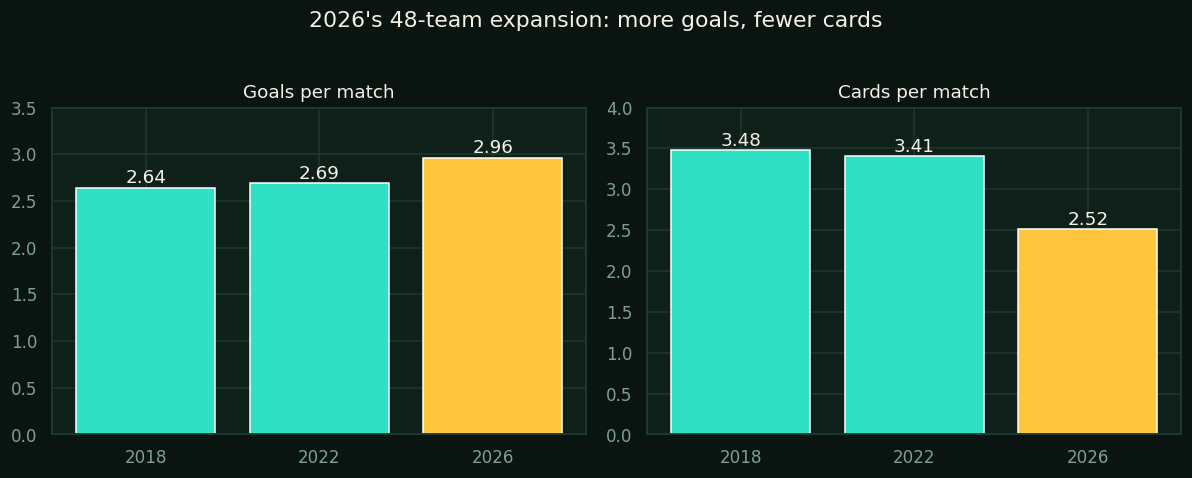

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))

axes[0].bar(historical.year.astype(str), historical.goals_per_match, color=[TEAL, TEAL, GOLD])
axes[0].set_title("Goals per match", color="#F4F1E6")
axes[0].set_ylim(0, 3.5)
for i,v in enumerate(historical.goals_per_match):
    axes[0].text(i, v+0.05, f"{v:.2f}", ha='center', color="#F4F1E6")

axes[1].bar(historical.year.astype(str), historical.cards_per_match, color=[TEAL, TEAL, GOLD])
axes[1].set_title("Cards per match", color="#F4F1E6")
axes[1].set_ylim(0, 4)
for i,v in enumerate(historical.cards_per_match):
    axes[1].text(i, v+0.05, f"{v:.2f}", ha='center', color="#F4F1E6")

plt.suptitle("2026's 48-team expansion: more goals, fewer cards", color="#F4F1E6", y=1.03)
plt.tight_layout()
plt.show()


**Takeaway:** the 48-team expansion did not water down the football. Goals per match actually rose to 2.96, the highest of the three tournaments, likely driven by mismatched group-stage fixtures against newly-qualified lower-ranked sides. Discipline improved at the same time: 2.52 cards per match, noticeably down from both 2018 and 2022.

## 3. Shock wins and statement draws

**Methodology:** every completed match is compared against both teams' pre-tournament FIFA ranking (as of June 11, 2026). A *shock win* is a match where the lower-ranked team won outright by a ranking gap of 15+ places. A *statement draw* is a drawn match with a ranking gap of 20+ places, i.e. the lower-ranked side didn't win, but denied a significantly stronger opponent the win entirely.

In [7]:
rank_lookup = dict(zip(teams.team_name, teams.fifa_ranking_pre_tournament))
name_fix = {"Cabo Verde": "Cape Verde"}
def rk(name): return rank_lookup.get(name)
def dn(name): return name_fix.get(name, name)

rows = []
for _, m in completed.iterrows():
    rh, ra = rk(m.home_team_name), rk(m.away_team_name)
    if rh is None or ra is None: continue
    gap = abs(rh - ra)
    if m.home_score == m.away_score:
        kind = 'statement_draw' if gap >= 20 else None
    else:
        winner, loser = (m.home_team_name, m.away_team_name) if m.home_score > m.away_score else (m.away_team_name, m.home_team_name)
        wr, lr = (rh, ra) if m.home_score > m.away_score else (ra, rh)
        kind = 'shock_win' if (wr > lr and wr - lr >= 15) else None
    if kind:
        rows.append({
            'stage': m.stage_name, 'kind': kind, 'gap': gap,
            'home': dn(m.home_team_name), 'away': dn(m.away_team_name),
            'score': f"{m.home_score}-{m.away_score}",
        })

upsets = pd.DataFrame(rows).sort_values('gap', ascending=False)
upsets.head(10)


,stage,kind,gap,home,away,score
3,Group Stage,statement_draw,65,Spain,Cape Verde,0-0
6,Group Stage,statement_draw,65,IR Iran,New Zealand,2-2
11,Group Stage,statement_draw,59,Ecuador,Curaçao,0-0
7,Group Stage,statement_draw,56,Portugal,Congo DR,1-1
12,Group Stage,statement_draw,51,Uruguay,Cape Verde,2-2
14,Group Stage,statement_draw,45,England,Ghana,0-0
17,Round of 32,statement_draw,44,Germany,Paraguay,1-1
5,Group Stage,statement_draw,42,Saudi Arabia,Uruguay,1-1
18,Round of 16,shock_win,38,Brazil,Norway,1-2
15,Group Stage,shock_win,38,South Africa,South Korea,1-0


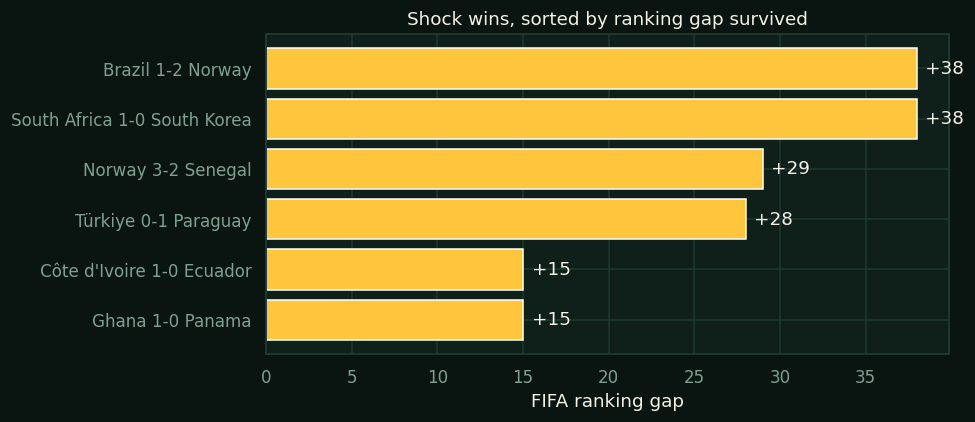

In [8]:
shocks = upsets[upsets.kind=='shock_win'].copy()
shocks['label'] = shocks.home + ' ' + shocks.score + ' ' + shocks.away

fig, ax = plt.subplots(figsize=(9, 0.5*len(shocks)+1))
bars = ax.barh(shocks.label[::-1], shocks.gap[::-1], color=GOLD)
ax.set_xlabel("FIFA ranking gap")
ax.set_title("Shock wins, sorted by ranking gap survived", color="#F4F1E6")
for bar, gap in zip(bars, shocks.gap[::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f"+{gap}", va='center', color="#F4F1E6")
plt.tight_layout()
plt.show()


**Norway 2–1 Brazil in the Round of 16** is the tournament's biggest shock: a 38-place ranking gap, settled in the knockout stage rather than a dead group game.

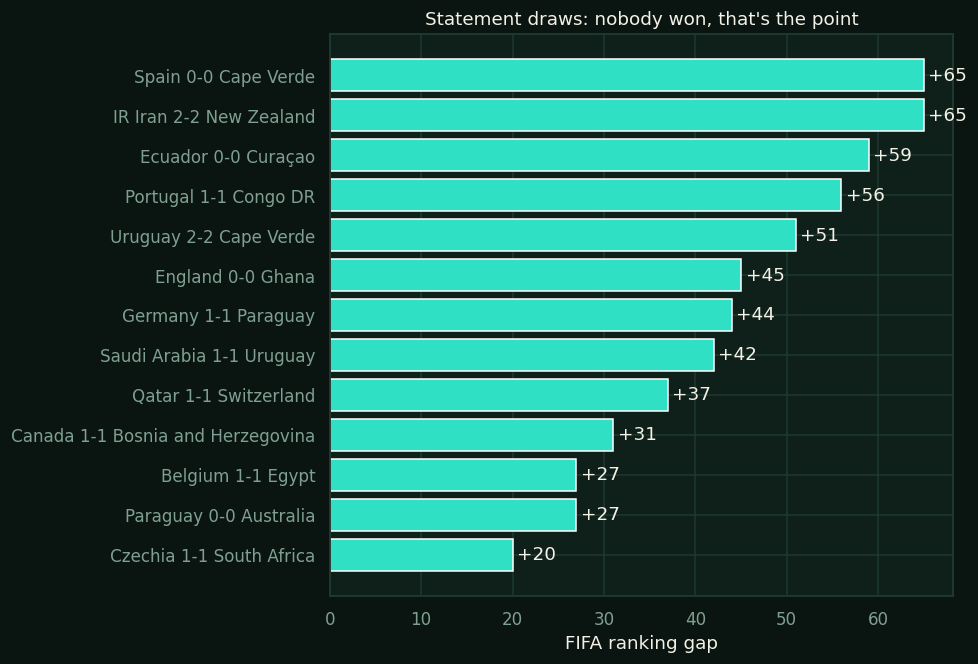

In [9]:
draws = upsets[upsets.kind=='statement_draw'].copy()
draws['label'] = draws.home + ' ' + draws.score + ' ' + draws.away

fig, ax = plt.subplots(figsize=(9, 0.4*len(draws)+1))
bars = ax.barh(draws.label[::-1], draws.gap[::-1], color=TEAL)
ax.set_xlabel("FIFA ranking gap")
ax.set_title("Statement draws: nobody won, that's the point", color="#F4F1E6")
for bar, gap in zip(bars, draws.gap[::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f"+{gap}", va='center', color="#F4F1E6")
plt.tight_layout()
plt.show()


**Spain 0–0 Cape Verde** on matchday one tops the list at a 65-place gap. It's the first sign of a story that runs all the way to the Round of 32.

## 4. The near misses: how close did the underdogs actually come?

Final scorelines flatten drama. A team that lost 3-2 after extra time might have led, twice, before finally losing. This section reconstructs goal-by-goal timelines for every knockout match where a big underdog (15+ rank gap) went to extra time or penalties.

In [10]:
def parse_minute(m):
    m = str(m)
    if '+' in m:
        base, extra = m.split('+')
        return float(base) + float(extra) * 0.1
    return float(m)

goal_events = events[events.event_type == 'Goal'].copy()
goal_events['minute_val'] = goal_events.minute.apply(parse_minute)

near_miss_candidates = completed[
    (completed.stage_name != 'Group Stage') &
    (completed.result_type.isin(['AET','Penalties']))
]

name_to_id = dict(zip(teams.team_name, teams.team_id))

nm_summary = []
for _, m in near_miss_candidates.iterrows():
    rh, ra = rk(m.home_team_name), rk(m.away_team_name)
    if rh is None or ra is None: continue
    gap = abs(rh - ra)
    if gap < 15: continue
    winner = m.home_team_name if m.home_score > m.away_score else m.away_team_name
    underdog = m.home_team_name if rh > ra else m.away_team_name
    if underdog != (m.home_team_name if m.home_score < m.away_score else m.away_team_name):
        continue
    nm_summary.append({'match_id': m.match_id, 'home': dn(m.home_team_name), 'away': dn(m.away_team_name),
                        'score': f"{m.home_score}-{m.away_score}", 'stage': m.stage_name,
                        'gap': gap, 'underdog': dn(underdog), 'winner': dn(winner)})

nm_df = pd.DataFrame(nm_summary).sort_values('gap', ascending=False)
nm_df


,match_id,home,away,score,stage,gap,underdog,winner
1,87,Argentina,Cape Verde,3-2,Round of 32,66,Cape Verde,Argentina
0,75,Germany,Paraguay,1-1,Round of 32,44,Paraguay,Paraguay
2,99,Norway,England,1-2,Quarter-finals,40,Norway,England
3,100,Argentina,Switzerland,3-1,Quarter-finals,18,Switzerland,Argentina


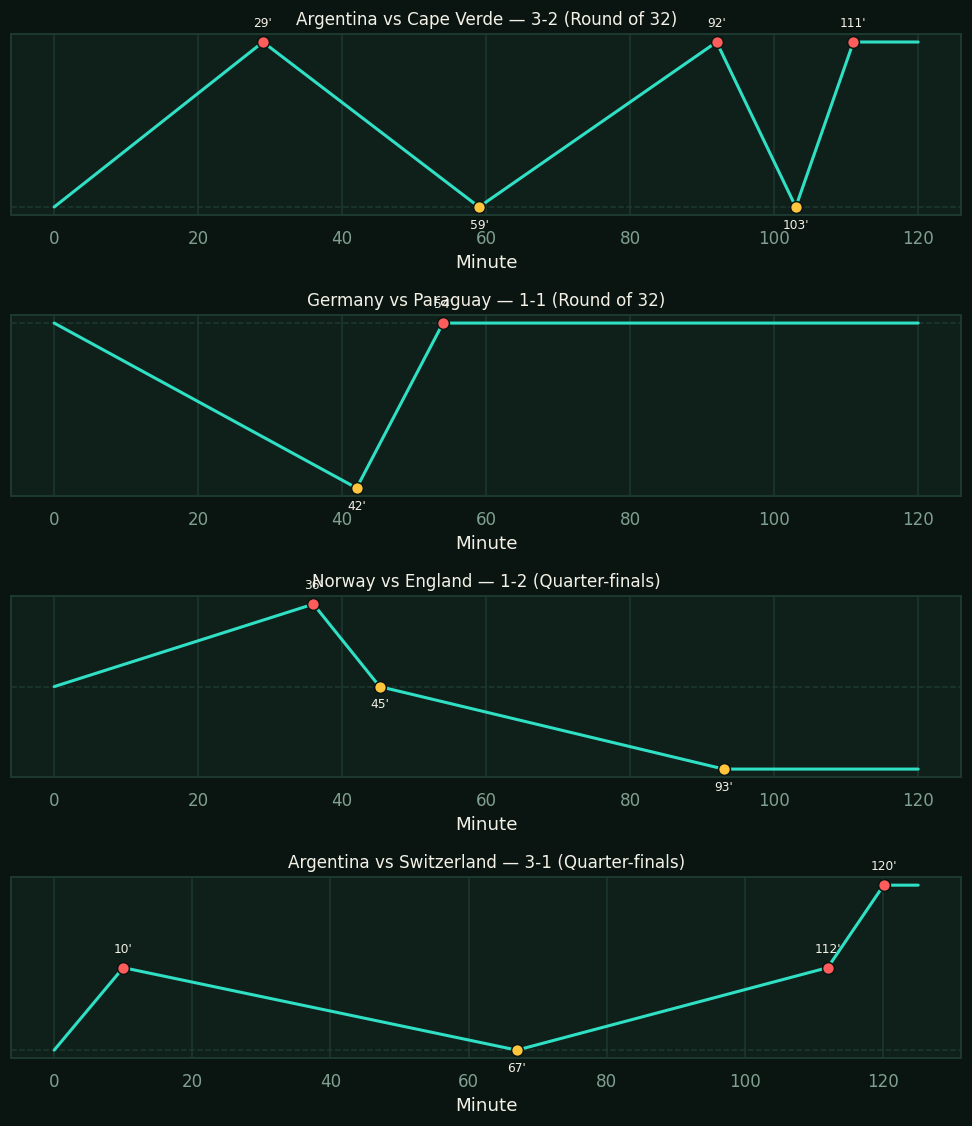

In [11]:
def plot_timeline(match_id, home_name, away_name, ax, title):
    home_id = name_to_id.get(home_name if home_name != 'Cape Verde' else 'Cabo Verde')
    g = goal_events[goal_events.match_id == match_id].sort_values('minute_val')
    running_h, running_a = 0, 0
    xs, ys = [0], [0]
    for _, ev in g.iterrows():
        if ev.team_id == home_id:
            running_h += 1
        else:
            running_a += 1
        xs.append(ev.minute_val)
        ys.append(running_h - running_a)
    xs.append(max(120, xs[-1]+5)); ys.append(ys[-1])
    ax.axhline(0, color="#1E3A30", linestyle='--', linewidth=1)
    ax.plot(xs, ys, color=TEAL, linewidth=2)
    for i in range(1, len(xs)-1):
        color = RED if ys[i] > ys[i-1] else GOLD
        ax.scatter(xs[i], ys[i], color=color, zorder=5, s=60, edgecolor="#0A1512")
        ax.annotate(f"{xs[i]:.0f}'", (xs[i], ys[i]), textcoords="offset points",
                    xytext=(0, 10 if ys[i]>=ys[i-1] else -14), ha='center', fontsize=8, color="#F4F1E6")
    ax.set_title(title, color="#F4F1E6", fontsize=11)
    ax.set_yticks([])
    ax.set_xlabel("Minute")

fig, axes = plt.subplots(len(nm_df), 1, figsize=(9, 2.6*len(nm_df)))
if len(nm_df) == 1: axes = [axes]
for ax, (_, row) in zip(axes, nm_df.iterrows()):
    plot_timeline(row.match_id, row.home, row.away, ax,
                  f"{row.home} vs {row.away} — {row.score} ({row.stage})")
plt.tight_layout()
plt.show()


**Cape Verde vs Argentina, Round of 32:** Argentina led at 29', Cape Verde equalized at 59', Argentina retook the lead in extra time at 92', Cape Verde equalized *again* at 103', and Argentina only won it at 111'. A team that didn't win a single group-stage match forced two separate comebacks out of the eventual runners-up.

## 5. Squad value vs. result: does money win World Cups?

In [12]:
value_rows = []
for _, r in features.iterrows():
    value_rows.append({'team': r.home_team_name, 'value': r.home_squad_total_value_eur})
    value_rows.append({'team': r.away_team_name, 'value': r.away_squad_total_value_eur})
values = pd.DataFrame(value_rows).drop_duplicates('team').set_index('team').value

stage_order = ['Group Stage','Round of 32','Round of 16','Quarter-finals','Semi-finals','Third-place match','Final']
last_stage = {}
for _, m in completed.iterrows():
    for side in [m.home_team_name, m.away_team_name]:
        cur = last_stage.get(side)
        if cur is None or stage_order.index(m.stage_name) > stage_order.index(cur):
            last_stage[side] = m.stage_name

vs_df = pd.DataFrame({
    'team': list(last_stage.keys()),
    'stage': list(last_stage.values()),
})
vs_df['stage_idx'] = vs_df.stage.map(stage_order.index)
vs_df['value_eur'] = vs_df.team.map(values)
vs_df['rank'] = vs_df.team.map(rank_lookup)
vs_df = vs_df.dropna()
vs_df.sort_values('value_eur', ascending=False).head(10)


,team,stage,stage_idx,value_eur,rank
24,Spain,Final,6,2.134173e+09,2
32,France,Third-place match,5,1.546204e+09,3
42,England,Third-place match,5,1.321819e+09,4
40,Portugal,Round of 16,2,1.145909e+09,5
36,Argentina,Final,6,1.025039e+09,1
16,Germany,Round of 32,1,9.887416e+08,10
10,Brazil,Round of 16,2,8.932324e+08,6
18,Netherlands,Round of 32,1,7.652175e+08,8
26,Belgium,Quarter-finals,3,6.340660e+08,9
20,Côte d'Ivoire,Round of 32,1,4.947663e+08,38


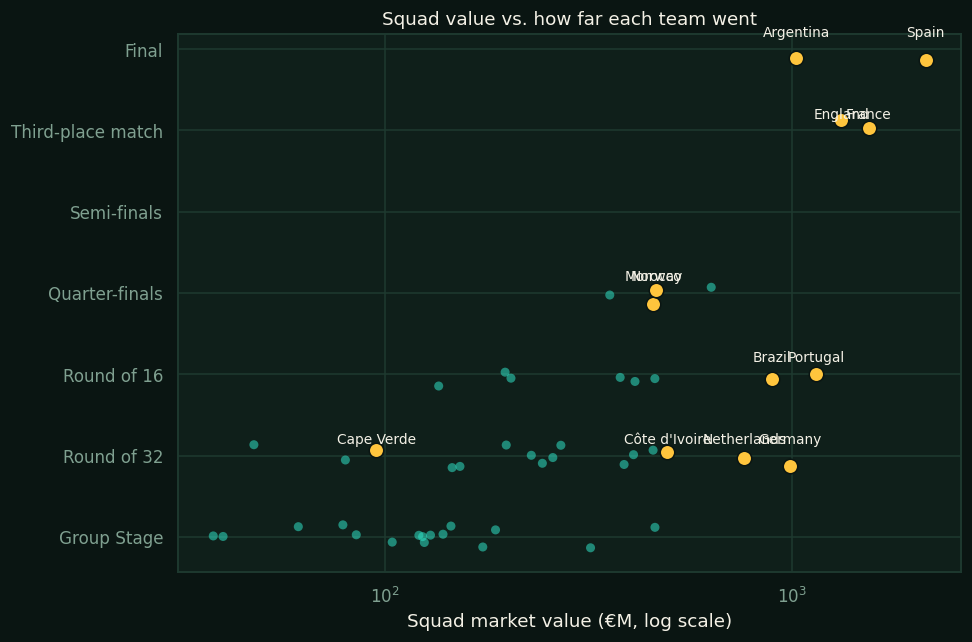

In [13]:
highlight = {'Spain','Argentina','France','England','Portugal','Germany','Brazil','Netherlands','Cabo Verde','Norway','Morocco', "Côte d'Ivoire"}

fig, ax = plt.subplots(figsize=(9,6))
for _, r in vs_df.iterrows():
    is_hi = r.team in highlight
    ax.scatter(r.value_eur/1e6, r.stage_idx + np.random.uniform(-0.15,0.15),
               color=GOLD if is_hi else TEAL, s=90 if is_hi else 35, alpha=1 if is_hi else 0.55,
               edgecolor='#0A1512' if is_hi else 'none', zorder=3 if is_hi else 2)
    if is_hi:
        ax.annotate(dn(r.team), (r.value_eur/1e6, r.stage_idx), textcoords="offset points",
                    xytext=(0,8), ha='center', fontsize=9, color="#F4F1E6")

ax.set_xscale('log')
ax.set_yticks(range(len(stage_order)))
ax.set_yticklabels(stage_order)
ax.set_xlabel("Squad market value (€M, log scale)")
ax.set_title("Squad value vs. how far each team went", color="#F4F1E6")
plt.tight_layout()
plt.show()


**Netherlands** had the 8th most valuable squad in the tournament (€765M) and went out in the Round of 32, the same round as **Cape Verde**, whose entire squad was worth roughly 4% of the Dutch wage bill.

## 6. Host nations: Mexico, USA, Canada

In [14]:
for host in ['Mexico','USA','Canada']:
    print(f"{host}: eliminated in the {last_stage.get(host)}")


Mexico: eliminated in the Round of 16
USA: eliminated in the Round of 16
Canada: eliminated in the Round of 16


First-ever tri-host World Cup, and all three hosts landed on exactly the same round: the Round of 16. No home-continent advantage story to force here, the flat result is the honest one.

## 7. Golden Boot vs. team success

In [15]:
goal_scorers = goal_events.drop(columns=['team_id']).merge(squads[['player_id','player_name','team_id']], on='player_id', how='left')
goal_scorers = goal_scorers.merge(teams[['team_id','team_name']], on='team_id', how='left')
top_scorers = goal_scorers.groupby(['player_name','team_name']).size().reset_index(name='goals').sort_values('goals', ascending=False).head(8)
top_scorers


,player_name,team_name,goals
107,Kylian Mbappe,France,10
115,Lionel Andrés Messi,Argentina,8
55,Erling Braut Haaland,Norway,7
94,Jude Victor William Bellingham,England,7
73,Harry Edward Kane,England,6
128,Masour Ousmane Dembele,France,6
139,Mikel Oyarzabal,Spain,5
97,Julián Andrés Quinones,Mexico,4


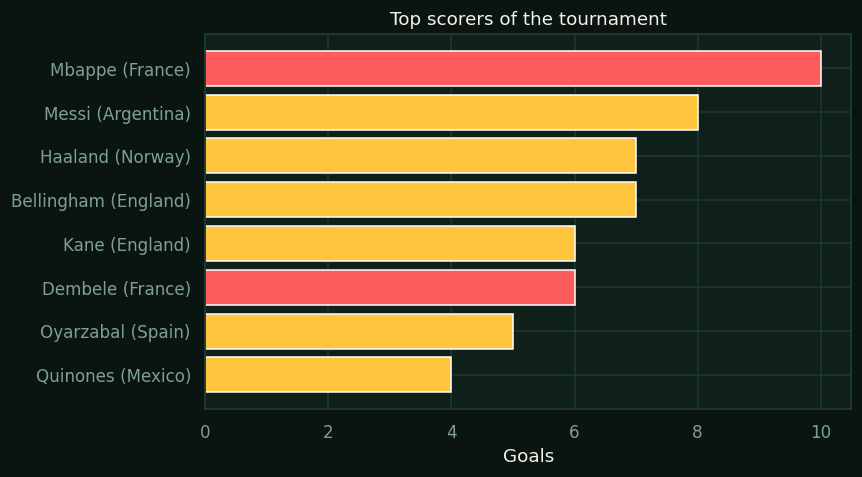

In [16]:
fig, ax = plt.subplots(figsize=(8,4.5))
labels = top_scorers.player_name.str.split().str[-1] + " (" + top_scorers.team_name + ")"
colors = [RED if t=='France' else GOLD for t in top_scorers.team_name]
ax.barh(labels[::-1], top_scorers.goals[::-1], color=colors[::-1])
ax.set_xlabel("Goals")
ax.set_title("Top scorers of the tournament", color="#F4F1E6")
plt.tight_layout()
plt.show()


Kylian Mbappé finishes as top scorer with 10 goals. His team, France, lost the third-place match 6–4 to England and finished the tournament in 4th place, outside the podium entirely.

## 8. Argentina's xG collapse in the final

In [17]:
arg_matches = completed[
    ((completed.home_team_name=='Argentina') | (completed.away_team_name=='Argentina')) &
    (completed.stage_name != 'Group Stage')
].copy()
arg_matches['stage_idx'] = arg_matches.stage_name.map(stage_order.index)
arg_matches = arg_matches.sort_values('stage_idx')

arg_matches['arg_xg'] = np.where(arg_matches.home_team_name=='Argentina', arg_matches.home_xg, arg_matches.away_xg)
arg_matches['opp_xg'] = np.where(arg_matches.home_team_name=='Argentina', arg_matches.away_xg, arg_matches.home_xg)
arg_matches['opponent'] = np.where(arg_matches.home_team_name=='Argentina', arg_matches.away_team_name, arg_matches.home_team_name)

arg_matches[['stage_name','opponent','home_score','away_score','arg_xg','opp_xg']]


,stage_name,opponent,home_score,away_score,arg_xg,opp_xg
86,Round of 32,Cabo Verde,3,2,2.16,0.46
94,Round of 16,Egypt,3,2,2.12,1.54
99,Quarter-finals,Switzerland,3,1,2.00,0.53
101,Semi-finals,England,1,2,1.80,0.54
103,Final,Spain,1,0,0.20,1.94


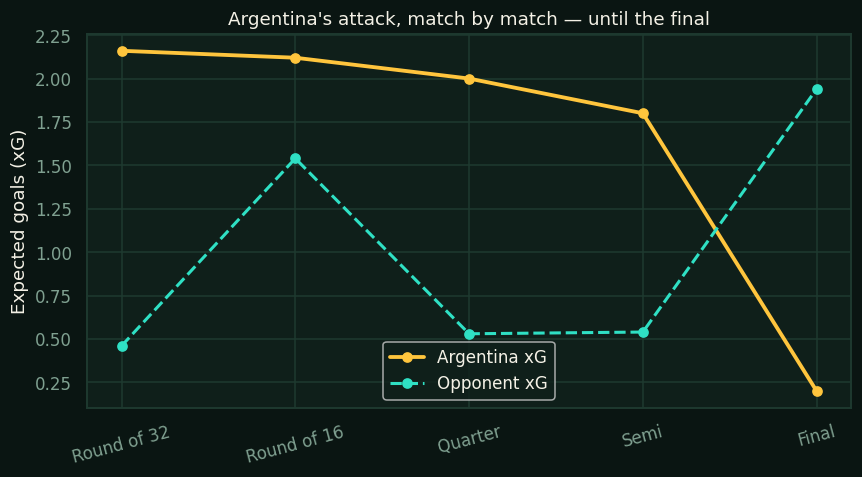

In [18]:
fig, ax = plt.subplots(figsize=(8,4.5))
x = range(len(arg_matches))
ax.plot(x, arg_matches.arg_xg, marker='o', color=GOLD, linewidth=2.5, label='Argentina xG')
ax.plot(x, arg_matches.opp_xg, marker='o', color=TEAL, linewidth=2, linestyle='--', label='Opponent xG')
ax.set_xticks(x)
ax.set_xticklabels(arg_matches.stage_name.str.replace(' Stage','').str.replace('-finals',''), rotation=15)
ax.set_ylabel("Expected goals (xG)")
ax.set_title("Argentina's attack, match by match — until the final", color="#F4F1E6")
ax.legend()
plt.tight_layout()
plt.show()


**The pattern is stark.** Argentina's xG holds at 2.0+ for three straight knockout rounds, then drops to 1.8 in the semifinal, then collapses to 0.20 in the final, their lowest output of the entire tournament, at the exact moment it mattered most. Spain won 1-0 in extra time off a stoppage-time Ferran Torres goal, and Enzo Fernández was sent off late.

---

## Conclusion

The 2026 World Cup expanded to 48 teams and, if anything, got *more* chaotic, not less: more goals per match than 2018 or 2022, six shock wins, thirteen statement draws, and a Cape Verde run that forced two separate comebacks out of the eventual runners-up before finally losing in the 111th minute. Spain won their second title in a final where the tournament's most fearsome attack simply never turned up.
